# HEART DISEASES PREDICTION - DATA SCIENCE PROJECT #

**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATASET**

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [4]:
df.tail(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.shape

(1025, 14)

**DATA CLEANING**

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(302, 14)

In [12]:
# Saved Cleaned Data
df.to_csv("cleaned_heart_data", index=False)

## Exploratory Data Analysis (EDA) ##

**CORRELATION HEATMAP**

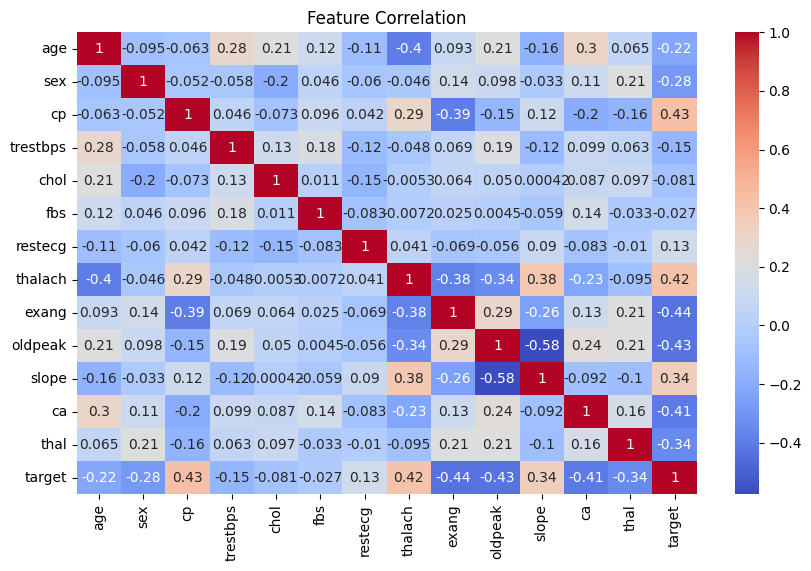

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.savefig("Heart_Disease_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### 1. KDE Plots for numeric columns grouped by target ###

In [14]:
sns.set(style="whitegrid")
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

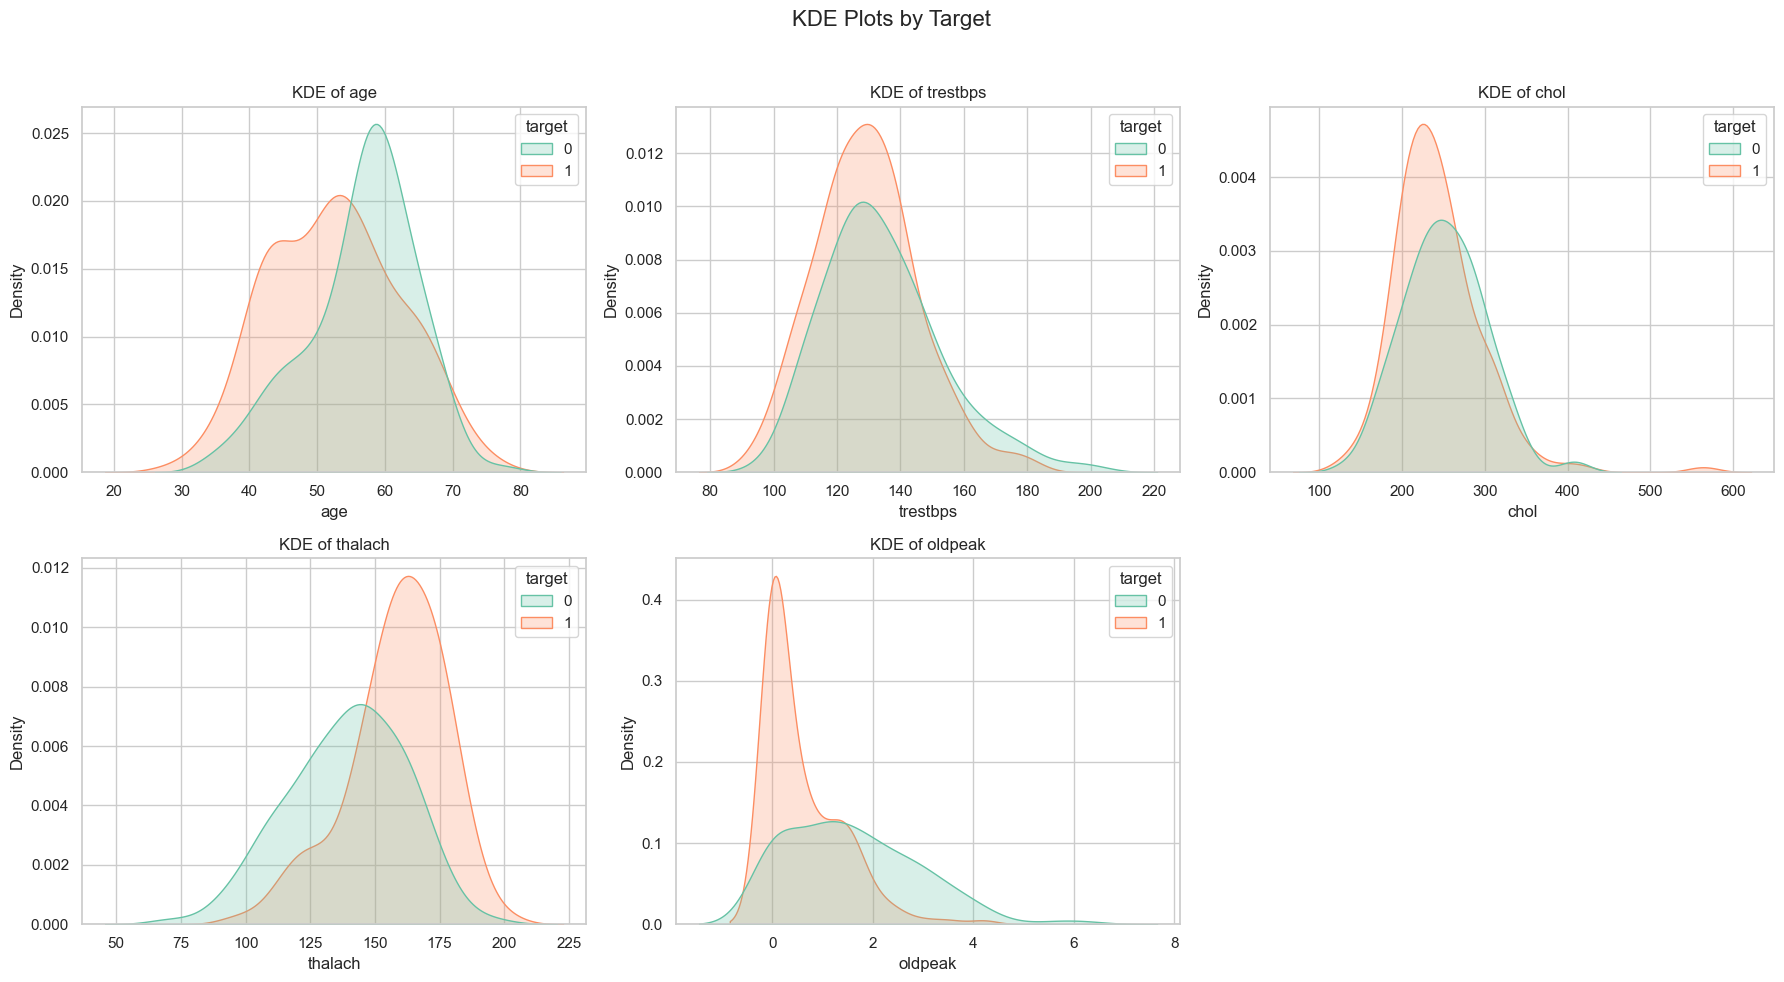

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, hue='target', fill=True, palette='Set2', ax=axes[i])
    axes[i].set_title(f"KDE of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

# Hide any extra subplot (if less than 6 plots)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("KDE Plots by Target", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Heart_Disease_KDE_PLot.png", dpi=300, bbox_inches="tight")
plt.show()

### 2. Violin plots to show distribution + density + median ###

C:\Users\sawma\AppData\Local\Temp\ipykernel_13760\2688569026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y=col, data=df, palette='coolwarm', ax=axes[i])
C:\Users\sawma\AppData\Local\Temp\ipykernel_13760\2688569026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y=col, data=df, palette='coolwarm', ax=axes[i])
C:\Users\sawma\AppData\Local\Temp\ipykernel_13760\2688569026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y=col, data=df, palette='coolwarm', ax=axes[i])
C:\Users\sawma\AppD

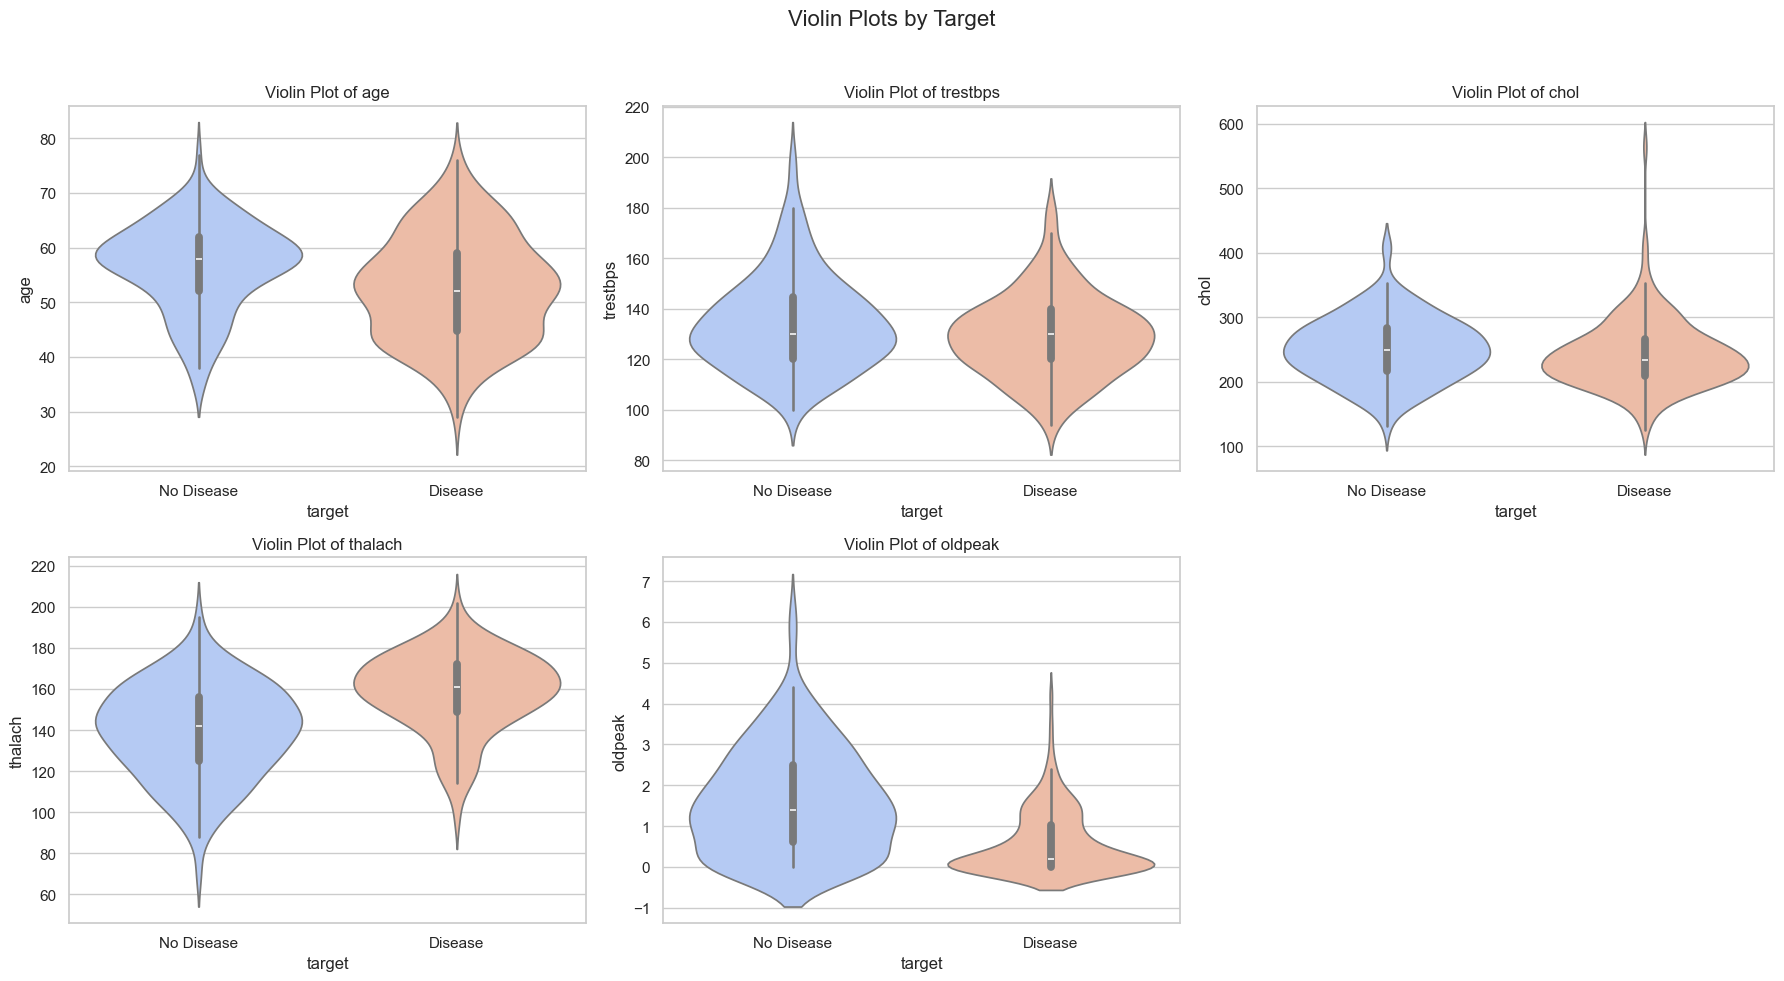

In [16]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(x='target', y=col, data=df, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f"Violin Plot of {col}")
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Violin Plots by Target", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Heart_Disease_violin_PLot.png", dpi=300, bbox_inches="tight")
plt.show()

### 3. Pairplot - full numeric relationships with target hue ###

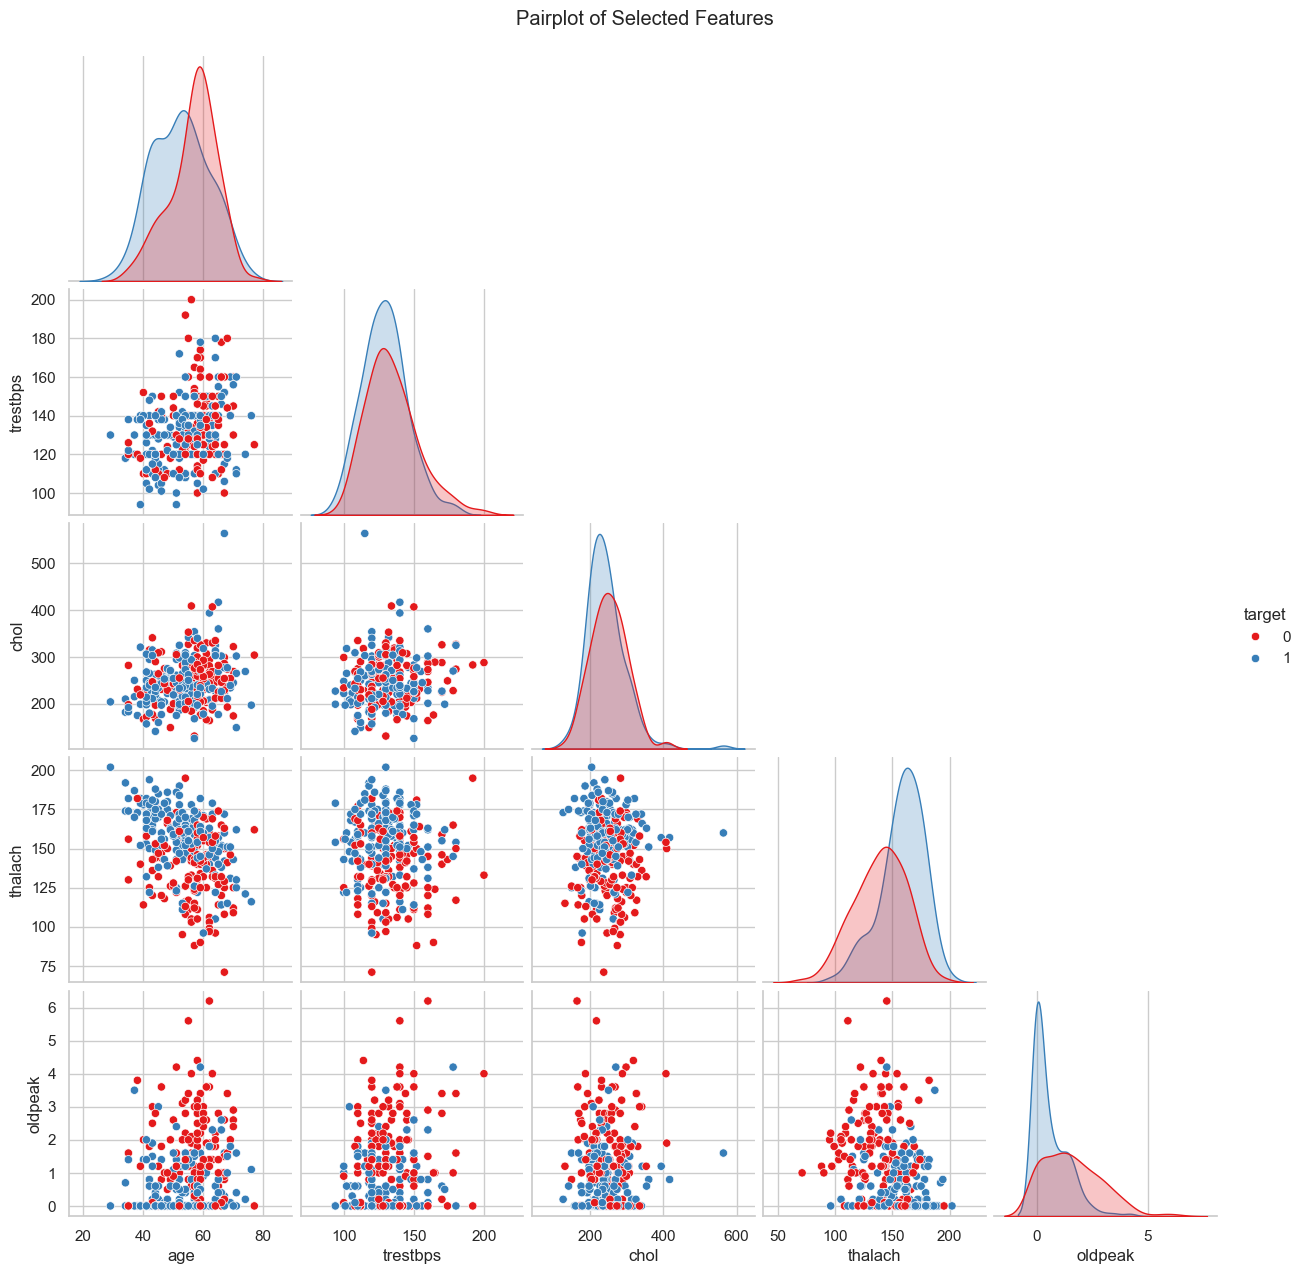

In [17]:
selected_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[selected_cols], hue='target', palette='Set1', corner=True, diag_kind='kde')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.savefig("Heart_Disease_Pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

### 4. Age group distribution analysis ###

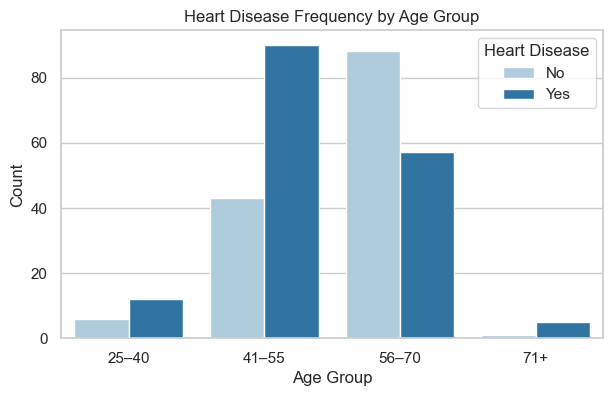

In [18]:
df['age_group'] = pd.cut(df['age'], bins=[25, 40, 55, 70, 100], labels=['25–40', '41–55', '56–70', '71+'])

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='age_group', hue='target', palette='Paired')
plt.title("Heart Disease Frequency by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])
plt.show()

### 5. Swarmplot - Max Heart Rate Archieved by Sex and Target ###

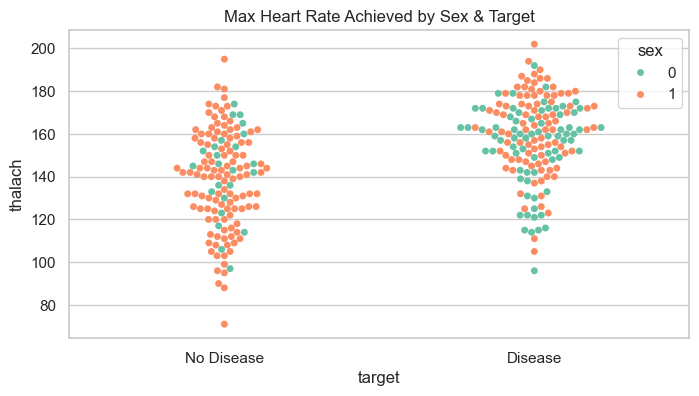

In [19]:
plt.figure(figsize=(8, 4))
sns.swarmplot(x='target', y='thalach', hue='sex', data=df, palette='Set2')
plt.title("Max Heart Rate Achieved by Sex & Target")
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.show()

### 6. Plot bar chart for 'sex'

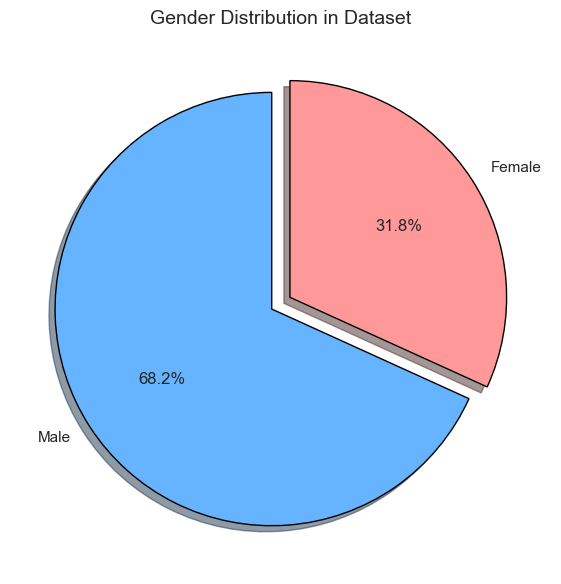

In [20]:
sex_counts = df['sex'].value_counts()
labels = ['Male', 'Female']  
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6,6))
plt.pie(sex_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops={'edgecolor': 'black'}, shadow=True, explode=(0.05, 0.05))
plt.title('Gender Distribution in Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,41–55
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,41–55
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,56–70
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,56–70
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,56–70


In [22]:
# Droping 'Age_Group' columns
df.drop(columns=['age_group',],inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [24]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [25]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

### TRAIN TEST AND SPLIT ###

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
#Separate Features and Target
x = df.drop('target', axis=1)
y = df['target']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

## MODEL 

## 1-> Logistic Regression ##

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Train a Model (Logistic Regression for baseline)**

In [31]:
log = LogisticRegression(max_iter=1000)
log.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred1= log.predict(x_test)

In [33]:
accuracy_score(y_test,y_pred1)

0.8032786885245902

**Evaluate**

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [35]:
y_pred = log.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, log.predict_proba(x_test)[:, 1]))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61

Confusion Matrix:
 [[21  7]
 [ 5 28]]
ROC AUC Score: 0.8668831168831168


## 2-> Random Forest Classifier ##

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [38]:
print("Random Forest ROC AUC:", roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1]))

Random Forest ROC AUC: 0.8722943722943723


###  Random Forest Evaluation ##

In [39]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [40]:
# Predict probabilities and classes
y_pred = rf.predict(x_test)
y_pred_proba = rf.predict_proba(x_test)[:, 1]

In [41]:
# Evaluation metrics
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

ROC AUC Score: 0.8722943722943723
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61

Confusion Matrix:
 [[20  8]
 [ 7 26]]


## 3-> XGBOOST Classifier ##

In [42]:
from xgboost import XGBClassifier

In [43]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(x_train, y_train)

C:\Users\sawma\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:57:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(x_test)[:, 1]))

XGBoost ROC AUC: 0.8322510822510822


### XGBoost Evaluation ##

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [46]:
# Predictions
y_pred_xgb = xgb.predict(x_test)
y_proba_xgb = xgb.predict_proba(x_test)[:, 1]  # Probability for

In [47]:
# Evaluation
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.68      0.69        28
           1       0.74      0.76      0.75        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61

XGBoost Confusion Matrix:
 [[19  9]
 [ 8 25]]
XGBoost ROC AUC Score: 0.8322510822510822


### Comparing Model accuracy  via Diagram chart 

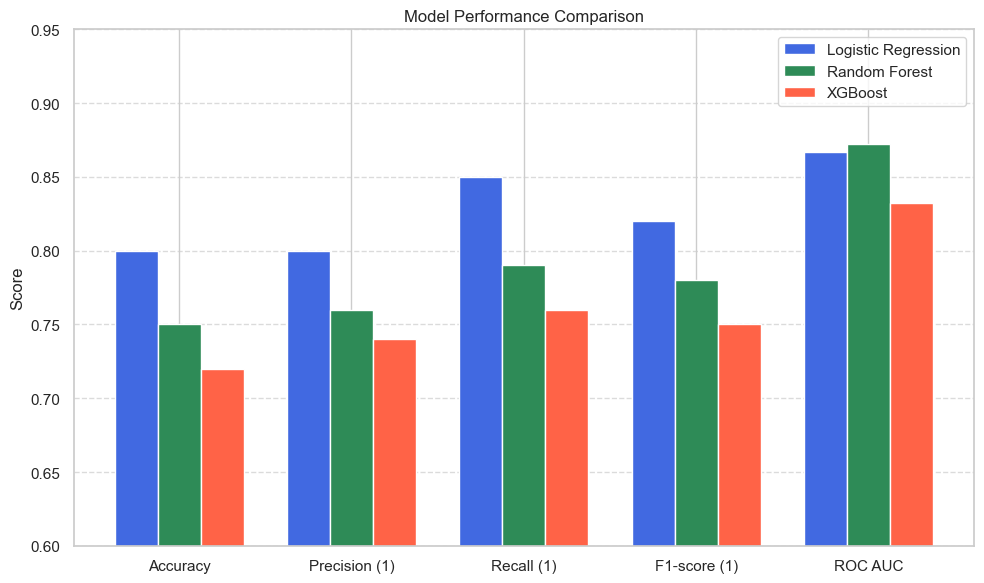

In [48]:
labels = ['Accuracy', 'Precision (1)', 'Recall (1)', 'F1-score (1)', 'ROC AUC']
logreg_scores = [0.80, 0.80, 0.85, 0.82, 0.867]
rf_scores = [0.75, 0.76, 0.79, 0.78, 0.872]
xgb_scores = [0.72, 0.74, 0.76, 0.75, 0.832]

x = np.arange(len(labels))  # label locations
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, logreg_scores, width, label='Logistic Regression', color='royalblue')
plt.bar(x, rf_scores, width, label='Random Forest', color='seagreen')
plt.bar(x + width, xgb_scores, width, label='XGBoost', color='tomato')

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, labels)
plt.ylim(0.6, 0.95)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Heart_Disease_model.png", dpi=300, bbox_inches="tight")
plt.show()

### Prediction Test

In [49]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [50]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [51]:
new_data = pd.DataFrame({
    'age':69,
    'sex':1,
    'cp':0,
    'trestbps':110,
    'chol':200,
    'fbs':0,
    'restecg':1,
    'thalach':160,
    'exang':0,
    'oldpeak':1.0,
    'slope':2,
    'ca':2,
    'thal':3
},index=[0])

In [52]:
new_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,69,1,0,110,200,0,1,160,0,1.0,2,2,3


**Predict**

In [53]:
p=log.predict(new_data)

if p[0]==0:
    print("No Disease")
else:
    print("Disease")

No Disease


## 💠Save best Model Using Joblib (Logistic Regression) ##

In [54]:
import joblib
joblib.dump(log,'log,model_joblib_heart')
model = joblib.load('log,model_joblib_heart')
model.predict(new_data)

array([0])